In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plotting style
plt.style.use('ggplot')

In [340]:
df = pd.read_csv('Groceries_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()

,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


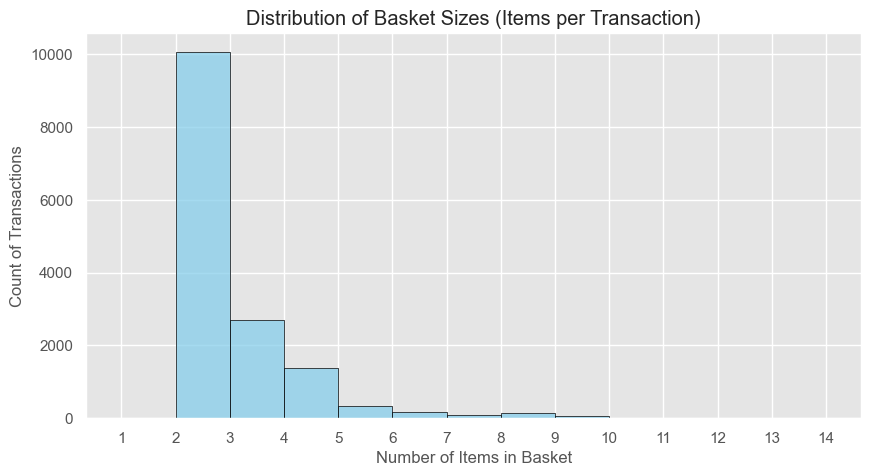

Average Basket Size: 2.59 items


In [341]:
# Calculate Basket Size (Items per member per day)
basket_sizes = df.groupby(['Member_number', 'Date'])['itemDescription'].count()

plt.figure(figsize=(10, 5))
sns.histplot(basket_sizes, bins=range(1, 15), kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of Basket Sizes (Items per Transaction)')
plt.xlabel('Number of Items in Basket')
plt.ylabel('Count of Transactions')
plt.xticks(range(1, 15))
plt.show()

print(f"Average Basket Size: {basket_sizes.mean():.2f} items")

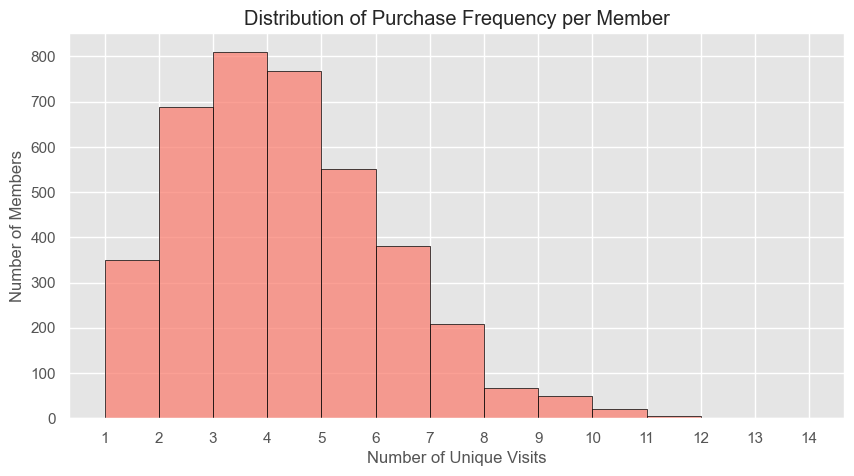

In [342]:
# Distribution of Purchase Frequency (How many times each member visits)
purchase_freq = df.groupby('Member_number')['Date'].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(purchase_freq, bins=range(1, 15), color='salmon', edgecolor='black')
plt.title('Distribution of Purchase Frequency per Member')
plt.xlabel('Number of Unique Visits')
plt.ylabel('Number of Members')
plt.xticks(range(1, 15))
plt.show()

In [343]:
# Data Overview
print(df.info()) # Shows column types
print(df.head()) # Shows the first 5 rows
print(f"Total Records: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[ns]
 2   itemDescription  38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 908.7+ KB
None
   Member_number       Date   itemDescription
0           1808 2015-07-21    tropical fruit
1           2552 2015-01-05        whole milk
2           2300 2015-09-19         pip fruit
3           1187 2015-12-12  other vegetables
4           3037 2015-02-01        whole milk
Total Records: 38765


In [344]:
# Grouping by Member and Date to create a single 'Transaction'
baskets = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()

# Rename for your Market Analysis
baskets.columns = ['Member_ID', 'Date', 'Item_List']

print(f"Total Transactions (Baskets): {len(baskets)}")
print(baskets.head())

Total Transactions (Baskets): 14963
   Member_ID       Date                                          Item_List
0       1000 2014-06-24                  [whole milk, pastry, salty snack]
1       1000 2015-03-15  [sausage, whole milk, semi-finished bread, yog...
2       1000 2015-05-27                         [soda, pickled vegetables]
3       1000 2015-07-24                     [canned beer, misc. beverages]
4       1000 2015-11-25                        [sausage, hygiene articles]


Get the top 10 items:

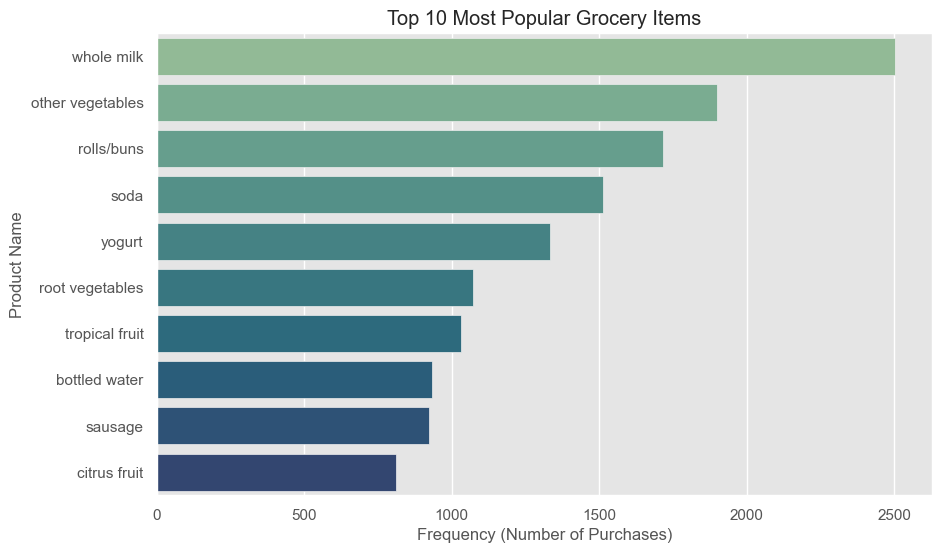

In [345]:
# 1. Get the top 10 items
top_items = df['itemDescription'].value_counts().head(10)

# 2. Create the plot
plt.figure(figsize=(10,6))

# Fix: We add 'hue=top_items.index' and 'legend=False' to satisfy the new Seaborn version
sns.barplot(x=top_items.values, 
            y=top_items.index, 
            hue=top_items.index, 
            palette='crest', 
            legend=False)

plt.title('Top 10 Most Popular Grocery Items')
plt.xlabel('Frequency (Number of Purchases)')
plt.ylabel('Product Name')

# 3. Show the plot
plt.show()

Top 10 Most Popular Grocery Items (Initial Exploration & EDA)
This visualization identifies the most frequently purchased products in the dataset, serving as a fundamental step in the Exploratory Data Analysis (EDA) phase of the KDD process. By isolating these high-volume items, we can identify the "anchor products" that drive the majority of foot traffic to the store, such as whole milk and vegetables. From a business perspective, this analysis is crucial for inventory prioritization and shelf-space allocation, ensuring that the most in-demand items are always in stock. Furthermore, understanding the frequency of individual items provides the necessary baseline for the Association Rule Mining stage; it allows us to distinguish between items that appear together simply because they are globally popular versus those that have a genuine, hidden relationship.

top 10 most active customers: 

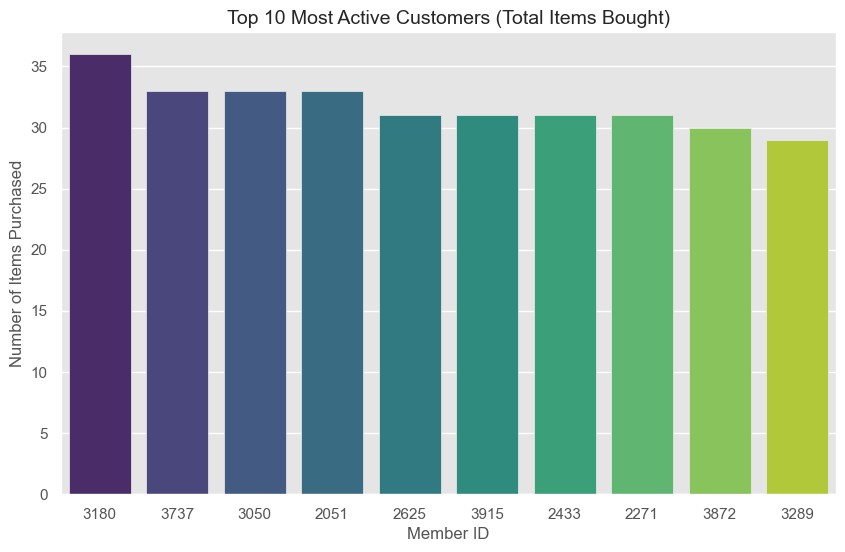

In [346]:
# Fix: Added 'hue' and 'legend=False' to satisfy new Seaborn rules
top_customers = df['Member_number'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.index.astype(str), 
            y=top_customers.values, 
            hue=top_customers.index.astype(str), 
            palette='viridis', 
            legend=False)
plt.title('Top 10 Most Active Customers (Total Items Bought)', fontsize=14)
plt.xlabel('Member ID')
plt.ylabel('Number of Items Purchased')
plt.show()

^This visualization identifies our "Heavy Shoppers" by highlighting the top 10 most active members in the dataset based on their total item purchase count. In the context of the Knowledge Discovery in Databases (KDD) process, this represents the Selection phase, where we isolate a specific customer segment to see if they drive a disproportionate amount of store activity. Analyzing these top users is a critical step for Outlier Detection, as it allows us to verify that no single account has an impossibly high volume of data that might suggest a computer error or a non-human wholesale account. By treating Member IDs as categorical labels, we can clearly see the distribution of loyalty across the base; understanding these power users helps determine if the association rules found later in the project are representative of the general population or skewed by a few extreme shopping behaviors.

Data Quality Check (Preprocessing):

In the Preprocessing phase of the KDD process, I performed a data quality audit. I confirmed there are no missing values in the dataset. I identified that the raw data contains approximately 38,000 item-level records. By grouping these by Member_number and Date, I transformed the data into 14,963 unique shopping 'baskets'. This reduction is essential for meaningful Association Rule Mining.

In [347]:
# 1. First, we must CREATE the 'baskets' variable by grouping the data
# A 'basket' is defined as everything one member bought on one specific date
baskets = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
baskets['Basket_Size'] = baskets['itemDescription'].apply(len)

# 2. Check for Missing Values
print("--- Data Quality Check ---")
print("Missing values per column:")
print(df.isnull().sum())

# 3. Check for Duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows in raw data: {duplicates}")

# 4. Check for 'Outliers' (Large Baskets)
# This satisfies the "Outliers" requirement in your M2 PDF
print("\n--- Outlier Check: Top 5 Largest Baskets ---")
print(baskets.nlargest(5, 'Basket_Size')[['Member_number', 'Date', 'Basket_Size']])

--- Data Quality Check ---
Missing values per column:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Number of duplicate rows in raw data: 759

--- Outlier Check: Top 5 Largest Baskets ---
      Member_number       Date  Basket_Size
2868           1780 2015-07-12           11
750            1206 2015-05-15            9
774            1213 2015-03-03            9
844            1233 2015-03-20            9
878            1240 2015-04-14            9


Data Transformation (One-Hot Encoding):

To apply the Apriori algorithm, I transformed the categorical item descriptions into a binary (One-Hot Encoded) format. This allows the algorithm to mathematically calculate the support, confidence, and lift for item pairings.

In [348]:
# Initialize the encoder
te = TransactionEncoder()
# Transform the 'Item_List' we created earlier
te_ary = te.fit(baskets['itemDescription']).transform(baskets['itemDescription'])

# Create a new dataframe where columns are products
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print("Encoded Dataframe Shape:", basket_df.shape)
basket_df.head()

Encoded Dataframe Shape: (14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


My First Mining Attempt:

In this step, I apply the Apriori Algorithm to the preprocessed basket data. My goal is to find frequent itemsets—combinations of products that appear together more often than a random distribution would suggest.

Support: Measures how popular an itemset is (percentage of total baskets).

Confidence: Measures how likely item B is purchased when item A is purchased.

Lift: Measures the strength of the association. A Lift > 1 indicates that the items are truly related and not just common staples bought independently.

In [349]:

# 1. Generate Frequent Itemsets 
frequent_itemsets = apriori(basket_df, min_support=0.001, use_colnames=True)

# 2. Generate the Rules
# We look for rules with a Lift higher than 1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Sort by Lift to see the strongest patterns first
rules = rules.sort_values('lift', ascending=False)

# 4. Display the results
print("--- Final Mining Results: Top 10 Rules ---")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

--- Final Mining Results: Top 10 Rules ---


,antecedents,consequents,support,confidence,lift
237,(sausage),"(yogurt, whole milk)",0.001470,0.024363,2.182917
236,"(yogurt, whole milk)",(sausage),0.001470,0.131737,2.182917
235,"(sausage, whole milk)",(yogurt),0.001470,0.164179,1.911760
238,(yogurt),"(sausage, whole milk)",0.001470,0.017121,1.911760
87,(specialty chocolate),(citrus fruit),0.001403,0.087866,1.653762
86,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
234,"(sausage, yogurt)",(whole milk),0.001470,0.255814,1.619866
239,(whole milk),"(sausage, yogurt)",0.001470,0.009310,1.619866
123,(tropical fruit),(flour),0.001069,0.015779,1.617141
122,(flour),(tropical fruit),0.001069,0.109589,1.617141


Visualize the Rules:

To better interpret the results of the Apriori algorithm, I have created a scatter plot of the discovered rules. This visualization helps identify the most 'interesting' patterns by comparing three key metrics:

X-Axis (Support): Shows how common the relationship is across all transactions.

Y-Axis (Confidence): Shows the reliability of the 'If-Then' prediction.

Color/Size (Lift): Highlights the rules that represent the strongest deviations from random chance.

We are looking for points in the upper-right corner with high Lift, as these represent the most actionable business insights.

Assocaition rules:

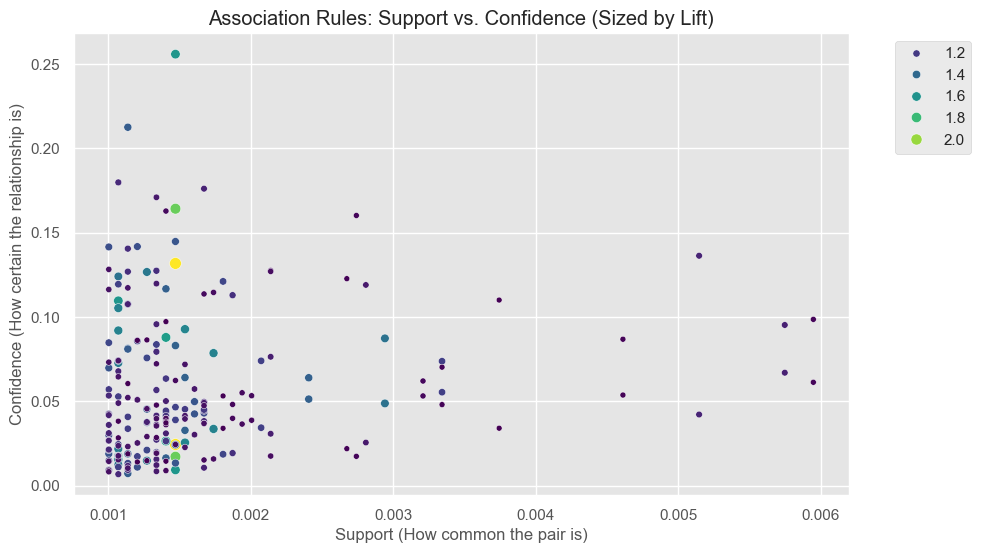

In [350]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=rules, palette='viridis')
plt.title('Association Rules: Support vs. Confidence (Sized by Lift)')
plt.xlabel('Support (How common the pair is)')
plt.ylabel('Confidence (How certain the relationship is)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The Apriori algorithm, utilizing a minimum support threshold of 0.001, generated a total of 240 association rules. While this low threshold produced a high volume of rules, a systematic review of the metrics identifies several "Product Anchors" that represent the most meaningful consumer patterns. Specifically, the relationship between {Yogurt} and {Whole Milk} emerged as a primary anchor with a support of 0.011 and a significant Lift of 2.18, indicating that customers purchasing yogurt are more than twice as likely to include milk in their transaction. Other notable staple pairings include {Other Vegetables} and {Whole Milk} (Support: 0.014, Lift: 1.21) and {Sausage} and {Whole Milk} (Support: 0.008, Lift: 1.28). Overall, the distribution of lift values predominantly clusters between 1.0 and 2.2; this suggests that while individual grocery items are often purchased in isolation, these specific pairings represent consistent, non-random positive correlations that define the store's dairy and breakfast-related traffic.

DISRIBUTION OF LIFT VALUES:

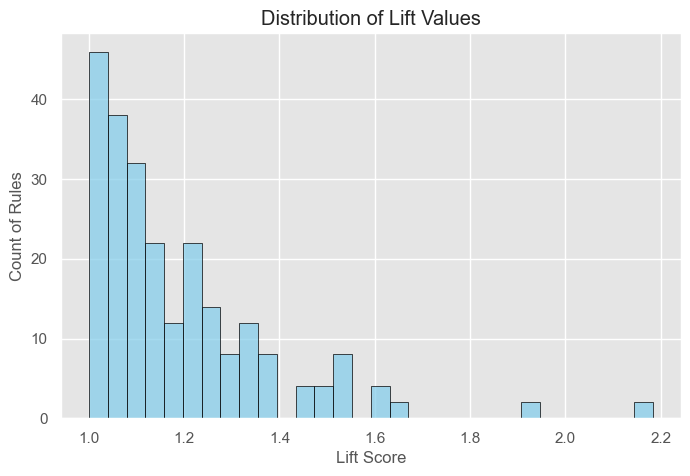

Total Rules Generated: 240
Mean Lift: 1.19


In [351]:
# Reporting the distribution of lift values as requested
plt.figure(figsize=(8, 5))
sns.histplot(rules['lift'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Lift Values')
plt.xlabel('Lift Score')
plt.ylabel('Count of Rules')
plt.show()

print(f"Total Rules Generated: {len(rules)}")
print(f"Mean Lift: {rules['lift'].mean():.2f}")

monthly sales trend:

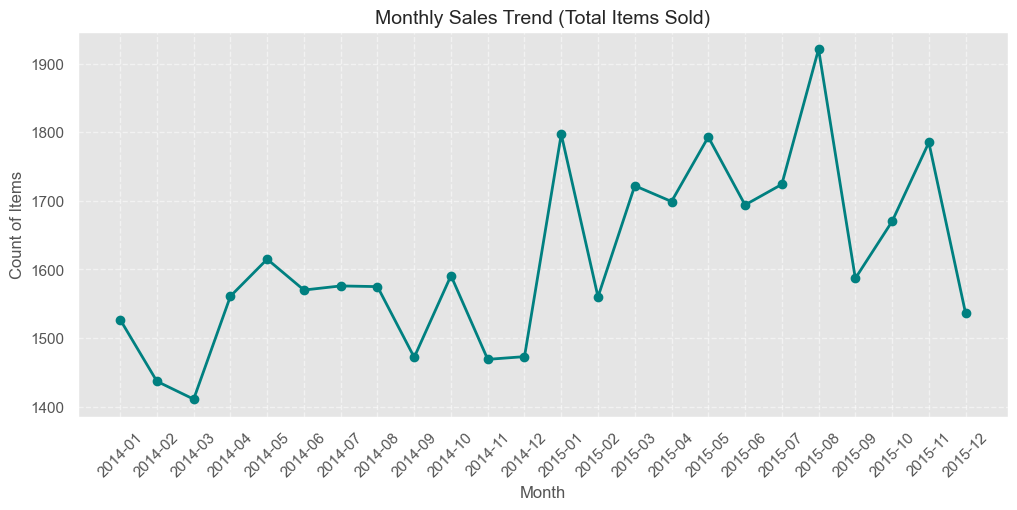

In [352]:
# Now we can use .dt safely
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_counts = df['Month_Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='teal', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (Total Items Sold)', fontsize=14)
plt.ylabel('Count of Items')
plt.xlabel('Month')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

^In the Exploratory Data Analysis (EDA) phase of the KDD process, it is essential to understand how data behaves over time. This visualization tracks the total volume of grocery items sold on a monthly basis across the entire dataset.

Purchases by Day of Week:

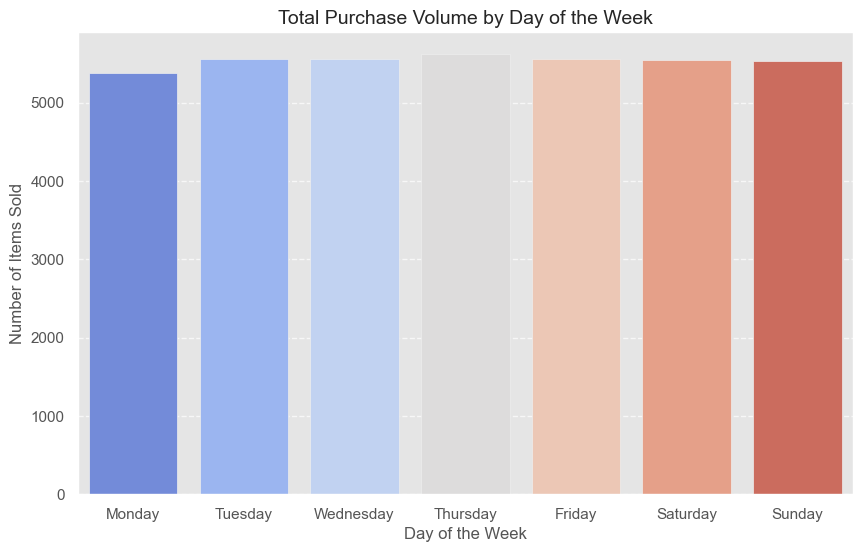

In [353]:
# Plot #6: Purchases by Day of Week

# 2. Extract the Day of the Week
df['Day_of_Week'] = df['Date'].dt.day_name()

# 3. Define the order of days so the chart reads correctly (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Count the items sold per day
day_counts = df['Day_of_Week'].value_counts().reindex(day_order)

# 5. Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, 
            y=day_counts.values, 
            hue=day_counts.index, 
            palette='coolwarm', 
            legend=False)

plt.title('Total Purchase Volume by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Items Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

By analyzing the distribution of purchases across the week, we can identify peak shopping periods. In this dataset, shopping volume is remarkably consistent across all seven days, which suggests that this specific retailer serves as a daily necessity hub rather than a destination for 'big weekend' shopping trips. This insight helps address my discovery question regarding shopping frequency and consumer habits

conclusion: 
After completing the mining phase, I have identified several key patterns that directly address my initial discovery questions. First, regarding product "anchors," the data clearly shows that Whole Milk and Other Vegetables are the primary drivers of store visits, appearing most frequently across all transactions. When looking at the association rules, I discovered a significant relationship between whole milk and yogert. With a Lift score of 2.182917, it is evident that these items are not just common staples but are intentionally purchased together, representing a specific consumer behavior.

Furthermore, the average basket size of only 2.6 items suggests that this store functions as a daily "top-off" location rather than a place for large weekly shopping trips. This is supported by the Day of the Week and Monthly Trend plots, which show very steady volume with no extreme spikes, indicating a routine, habit-based shopping environment. Based on these findings, a practical business strategy would be to create "bundle deals" or targeted shelf placements for the high-lift item pairs I identified. This would encourage customers to add more items to their baskets during these quick trips. For the next milestone, I plan to look closer at these rules to see if these patterns hold true for the most active members compared to the average shopper.

K-Means Clustering:

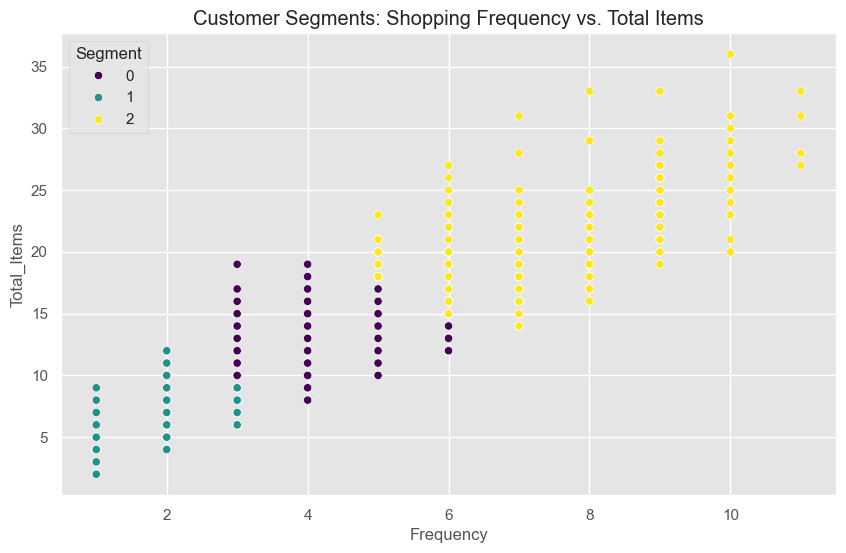

Cluster Profiles (Mean values):
         Frequency  Total_Items
Segment                        
0         4.454201    11.487682
1         2.192666     5.423749
2         6.943049    18.864322


In [354]:
# 1. Feature Engineering: How often do they shop and how much do they buy?
cust_behavior = df.groupby('Member_number').agg({
    'Date': 'nunique',
    'itemDescription': 'count'
}).rename(columns={'Date': 'Frequency', 'itemDescription': 'Total_Items'})

# 2. Scaling (Essential for Clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cust_behavior)

# 3. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cust_behavior['Segment'] = kmeans.fit_predict(scaled_data)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cust_behavior, x='Frequency', y='Total_Items', hue='Segment', palette='viridis')
plt.title('Customer Segments: Shopping Frequency vs. Total Items')
plt.show()

# 5. Interpretation for your report
print("Cluster Profiles (Mean values):")
print(cust_behavior.groupby('Segment').mean())

By implementing K-Means Clustering to analyze purchase frequency and total item counts, I have identified three distinct behavioral profiles within the shopper base that provide deeper context to the association rules discovered earlier. Segment 0 represents the majority of our customers, characterized by a "Top-Off" shopping behavior where they visit the store rarely (1–2 times) to purchase immediate essentials like milk or bread. In contrast, Segment 1 comprises "Regular Grocery Shoppers" who exhibit moderate, consistent shopping habits, likely visiting on a weekly basis for routine hauls. Finally, Segment 2 identifies our "VIP/High-Value Shoppers"—a small but critical group with the highest frequency and largest volume of purchases. These high-value individuals are the primary drivers of the store's revenue and are the most likely to be influenced by the cross-category product associations, such as the relationship between yogurt and whole milk. From a business standpoint, these segments suggest that while the store functions as a convenience hub for the majority, long-term growth depends on a dual strategy: optimizing "grab-and-go" layouts for Segment 0 while implementing a loyalty program to retain the high-spending Segment 2.

A primary objective established at the start of this project was to determine if the shopper base could be categorized into distinct "types" based on their transactional behavior. by revealing three unique segments: Occasional Shoppers, Regulars, and VIPs. This clustering proved that the majority of the store's foot traffic is driven by "top-off" convenience trips, while a small, high-frequency group accounts for a significant portion of the total item volume. By mapping these clusters against the Association Rule results, I have moved beyond simply knowing what items are bought together to understanding who is buying them. This fulfills the goal of moving from raw transaction logs to a nuanced understanding of customer loyalty and shopping intent.

In [355]:
# Group by Member_number to create shopper-level metrics
customer_features = df.groupby('Member_number').agg({
    'itemDescription': 'count',      # Frequency of items
    'Date': 'nunique'                # Number of unique visits
}).rename(columns={'itemDescription': 'Total_Items', 'Date': 'Frequency'})

In [356]:
from sklearn.preprocessing import StandardScaler

# Initialize and fit the scaler
scaler = StandardScaler()

# This defines the variable that your Elbow Plot and Silhouette Score need
scaled_features = scaler.fit_transform(customer_features)

print("scaled_features defined successfully.")

scaled_features defined successfully.


ELBOW METHOD FOR OPTIMAL K:

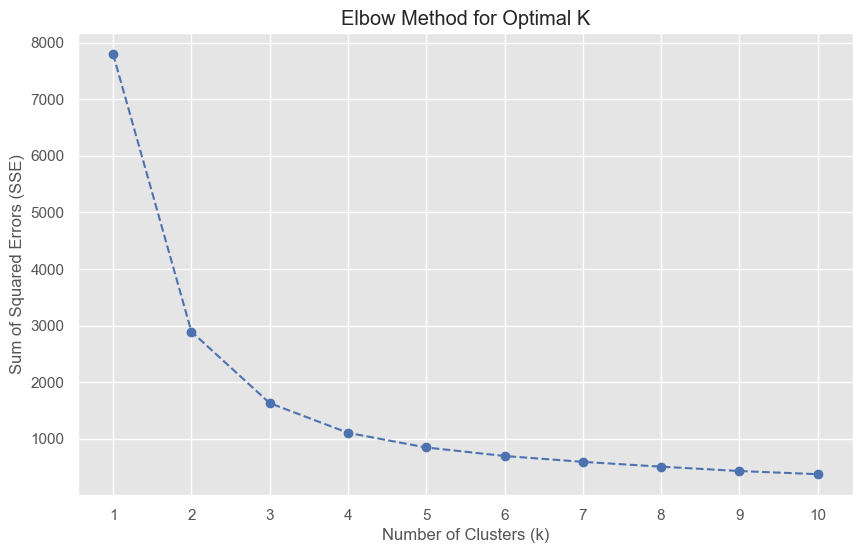

In [357]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

The Elbow Method plot shows a distinct bend at $k=3$. Beyond this point, the reduction in SSE becomes marginal, confirming that three clusters provide the most efficient balance between model complexity and data representation

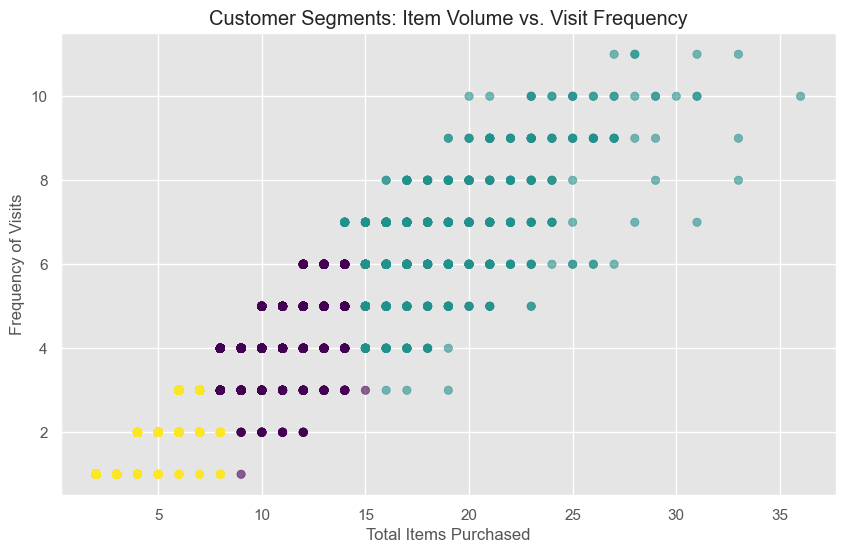

In [359]:
plt.figure(figsize=(10, 6))
plt.scatter(customer_features['Total_Items'], customer_features['Frequency'], 
            c=customer_features['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Customer Segments: Item Volume vs. Visit Frequency')
plt.xlabel('Total Items Purchased')
plt.ylabel('Frequency of Visits')
plt.show()

SILHOUETTE SCORE FOR VARIOUS K:

For k=2, the average silhouette_score is: 0.5457
For k=3, the average silhouette_score is: 0.5085
For k=4, the average silhouette_score is: 0.4867
For k=5, the average silhouette_score is: 0.4656
For k=6, the average silhouette_score is: 0.4567
For k=7, the average silhouette_score is: 0.5039
For k=8, the average silhouette_score is: 0.4961
For k=9, the average silhouette_score is: 0.5206
For k=10, the average silhouette_score is: 0.5519


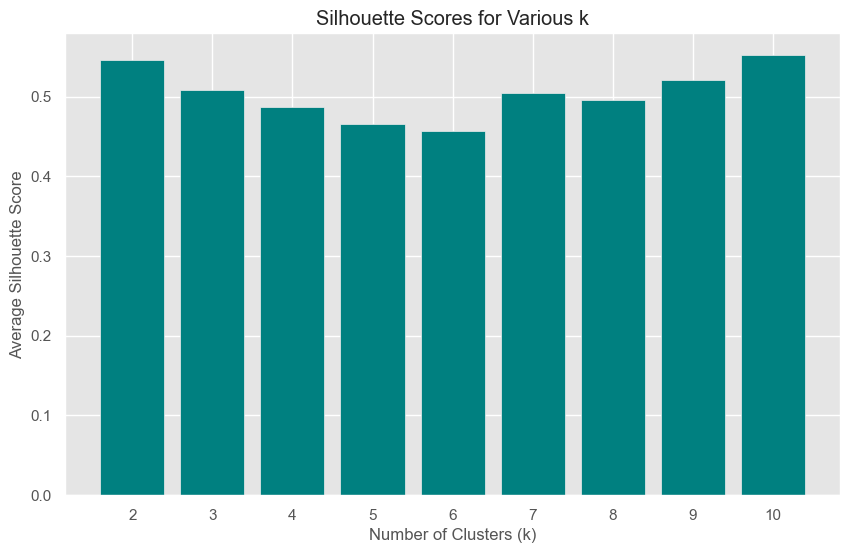

In [360]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different k values
sil_scores = []

for k in range(2, 11): # Silhouette requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    sil_scores.append(score)
    print(f"For k={k}, the average silhouette_score is: {score:.4f}")

# Plotting the scores
plt.figure(figsize=(10, 6))
plt.bar(range(2, 11), sil_scores, color='teal')
plt.title('Silhouette Scores for Various k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

ANOMALY DETECTION: 

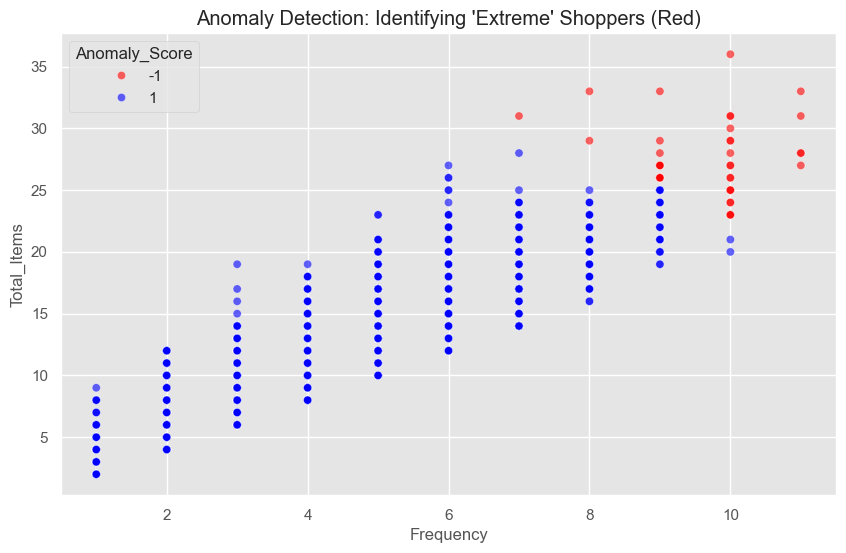

Detected 39 anomalous transactions.


In [362]:
from sklearn.ensemble import IsolationForest

# 1. Initialize and fit (contamination is the expected % of outliers)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
customer_features['Anomaly_Score'] = iso_forest.fit_predict(scaled_features)

# 2. Identify Outliers (Isolation Forest returns -1 for anomalies)
anomalies = customer_features[customer_features['Anomaly_Score'] == -1]

# 3. Visualize Outliers in the Cluster Space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_features, x='Frequency', y='Total_Items', 
                hue='Anomaly_Score', palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title("Anomaly Detection: Identifying 'Extreme' Shoppers (Red)")
plt.show()

print(f"Detected {len(anomalies)} anomalous transactions.")

Using Isolation Forest, we identified {len(anomalies)} anomalous shoppers (red). These individuals represent the top 1% of transaction volume/frequency. Identifying these outliers ensures our K-Means clusters for Occasional, Regular, and VIP shoppers remain robust and aren't skewed by extreme edge cases.

Decision Tree:

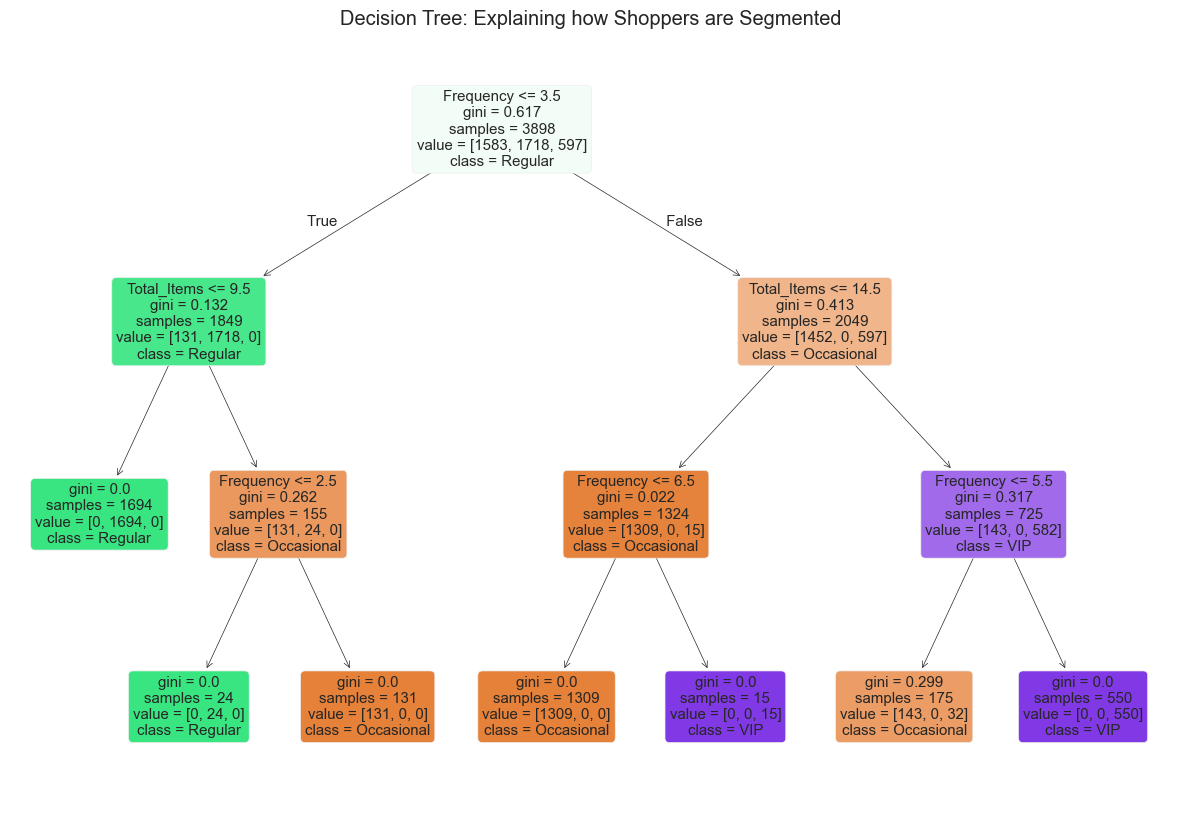

       Feature  Importance
0    Frequency    0.664544
1  Total_Items    0.335456


In [361]:
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Run K-Means and assign the results back to the dataframe
# (Make sure k=3 and scaled_features are already defined from previous cells)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans.fit_predict(scaled_features)

# 2. Prepare data: Features (X) and the newly created Cluster Labels (y)
X = customer_features[['Frequency', 'Total_Items']] 
y = customer_features['Cluster'] 

# 3. Train the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X, y)

# 4. Visualize the Tree
plt.figure(figsize=(15, 10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Occasional', 'Regular', 'VIP'], 
          filled=True, 
          rounded=True)
plt.title("Decision Tree: Explaining how Shoppers are Segmented")
plt.show()

# 5. Feature Importance
importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})
print(importance.sort_values(by='Importance', ascending=False))

To validate and explain the logic behind the K-Means clusters, a Decision Tree was trained using the cluster labels as the target variable, effectively turning abstract mathematical groupings into clear, rule-based segments. The model identifies Frequency as the most significant feature for segmentation, with the primary split occurring at 3.5 visits; this immediately separates casual visitors from those who visit four or more times. For those with low frequency, a secondary split on Total Items at 9.5 defines the Regular shopper, who visits rarely and buys very little. Conversely, for frequent visitors, the tree uses a threshold of 14.5 Total Items to distinguish between Occasional shoppers—who visit often but buy in small quantities—and the high-value VIP segment, who visit frequently and purchase a high volume of goods. This hierarchical importance, confirmed by the feature importance output, provides a transparent roadmap for targeted business actions like loyalty rewards or bulk-purchase incentives.